**Reinforcement Learning and Dynamic Optimization.**

Technical University of Crete

Assignment 2 (2025) - Price Optimization Using Bandits

Deadline: 28 Mar, 2025

Student: Karalis Asterinos

AM: 2020030107


Question 1 code description:
blah blah blah...

Iteration 1: Weights: [1. 1. 1. 1. 1.]
Iteration 2: Weights: [1. 1. 1. 1. 1.]
Iteration 3: Weights: [1.         1.         1.01834811 1.         1.        ]
Iteration 4: Weights: [1.         1.         1.03703288 1.         1.        ]
Iteration 5: Weights: [1.         1.         1.03703288 1.02764803 1.        ]
Iteration 6: Weights: [1.         1.00913236 1.03703288 1.02764803 1.        ]
Iteration 7: Weights: [1.         1.00913236 1.03703288 1.02764803 1.        ]
Iteration 8: Weights: [1.         1.00913236 1.03703288 1.02764803 1.0417574 ]
Iteration 9: Weights: [1.         1.00913236 1.03703288 1.05606048 1.0417574 ]
Iteration 10: Weights: [1.0045558  1.00913236 1.03703288 1.05606048 1.0417574 ]
Iteration 11: Weights: [1.00913236 1.00913236 1.03703288 1.05606048 1.0417574 ]
Iteration 12: Weights: [1.00913236 1.01834811 1.03703288 1.05606048 1.0417574 ]
Iteration 13: Weights: [1.00913236 1.02764803 1.03703288 1.05606048 1.0417574 ]
Iteration 14: Weights: [1.00913236 1.02764803 1.0

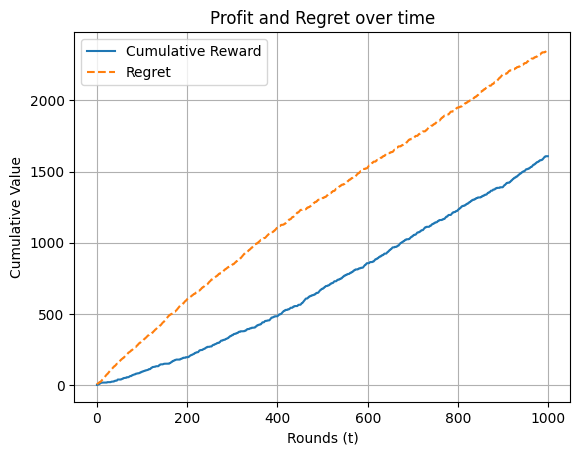

Final weights: [1.10015881e+00 1.26663482e+00 2.35030582e+00 2.26637541e+00
 2.11303606e+06]
Final price probabilities: [5.20651397e-07 5.99436355e-07 1.11228487e-06 1.07256471e-06
 9.99996695e-01]
Total reward after T rounds: 1607.9238830580402
Total regret after T rounds: 2362.258544245763


In [1]:
import numpy as np
import matplotlib.pyplot as plt

#student id -> 2020030107 -> seed:07

T = 1000
alpha = 0.5
beta = 1.5
price_options = ['p0', 'p1', 'p2', 'p3', 'p4']
P = np.random.uniform(1.5, 2.5)

prices = [
    alpha**2 * P,  # p0
    alpha * P,     # p1
    P,             # p2
    beta * P,      # p3
    beta**2 * P    # p4
]

np.random.seed(7)
weights = np.ones(5)
eta = 0.1

rewards = np.zeros(T)
picked_prices = np.zeros(T)
cumulative_rewards = np.zeros(T)
regrets = np.zeros(T)

"""
Regarding question 1:

Since the customer always agrees to pay after choosing,
it would be best to always suggest him the biggest price.
However we are tasked to assume this is not true
Then how do we proceed?
"""
best_possible_reward = np.max(prices)

for t in range(T):

    probabilities = weights / np.sum(weights)
    chosen_price_index = np.random.choice(5, p=probabilities)
    picked_prices[t] = prices[chosen_price_index]


    competitor_price = np.random.uniform(0, 4)
    user_picked_you = np.random.choice([True, False])

    reward = prices[chosen_price_index] if user_picked_you else 0
    rewards[t] = reward


    if reward > 0:  # only update if reward is earned
        weights[chosen_price_index] *= np.exp(eta * reward / np.sum(prices))

    cumulative_rewards[t] = np.sum(rewards[:t + 1])

    total_possible_reward = best_possible_reward * (t + 1)
    regrets[t] = total_possible_reward - cumulative_rewards[t]

    print(f"Iteration {t+1}: Weights: {weights}")


plt.plot(cumulative_rewards, label='Cumulative Reward')
plt.plot(regrets, label='Regret', linestyle='--')
plt.title('Profit and Regret over time')
plt.xlabel('Rounds (t)')
plt.ylabel('Cumulative Value')
plt.grid(True)
plt.legend()
plt.show()

final_probabilities = weights / np.sum(weights)
print("Final weights:", weights)
print("Final price probabilities:", final_probabilities)
print("Total reward after T rounds:", np.sum(rewards))
print("Total regret after T rounds:", regrets[-1])

Question 2 code description:
blah blah blah...

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# student id -> 2020030107 -> seed:07

T = 1000
alpha = 0.5
beta = 1.5
price_options = ['p0', 'p1', 'p2', 'p3', 'p4']
P = np.random.uniform(1.5, 2.5)

prices = [
    alpha**2 * P,  # p0
    alpha * P,     # p1
    P,             # p2
    beta * P,      # p3
    beta**2 * P    # p4
]

np.random.seed(7)
weights = np.ones(5)
eta = 0.1

rewards = np.zeros(T)
picked_prices = np.zeros(T)
cumulative_rewards = np.zeros(T)
regrets = np.zeros(T)

best_possible_reward = np.max(prices)
naive_rounds = T // 4

for t in range(T):
    probabilities = weights / np.sum(weights)
    chosen_price_index = np.random.choice(5, p=probabilities)
    picked_prices[t] = prices[chosen_price_index]

    if t < naive_rounds:
        competitor_price = np.random.uniform(0, 4)
        user_picked_you = np.random.choice([True, False])  # Random choice
        reward = prices[chosen_price_index] if user_picked_you else 0
    else:
        competitor_price = np.random.uniform(0, 4)
        if prices[chosen_price_index] <= competitor_price:
            reward = prices[chosen_price_index]
        else:
            reward = 0

    rewards[t] = reward
    if reward > 0:  # only update if reward is earned
        weights[chosen_price_index] *= np.exp(eta * reward / np.sum(prices))

    cumulative_rewards[t] = np.sum(rewards[:t + 1])
    total_possible_reward = best_possible_reward * (t + 1)
    regrets[t] = total_possible_reward - cumulative_rewards[t]

    #debbuging print to check weight prices.
    print(f"Iteration {t+1}: Weights: {weights}")

# Plot the cumulative reward and regret
plt.plot(cumulative_rewards, label='Cumulative Reward')
plt.plot(regrets, label='Regret', linestyle='--')
plt.title('Profit and Regret over time')
plt.xlabel('Rounds (t)')
plt.ylabel('Cumulative Value')
plt.grid(True)
plt.legend()
plt.show()

# Print final observations
final_probabilities = weights / np.sum(weights)
print("Final weights:", weights)
print("Final price probabilities:", final_probabilities)
print("Total reward after T rounds:", np.sum(rewards))
print("Total regret after T rounds:", regrets[-1])